<a href="https://colab.research.google.com/github/aasutoshz/Distribution-Grid-Optimal-Power-Flow-Models-DOPF/blob/main/branchflow_models/SDP/SDP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semi-Definite Programming Formulation for Optimal Power Flow (OPF)

implements a generalized branch-flow formulation, utilizing a semidefinite programming (SDP) relaxation to solve the three-phase Distribution Grid Optimal Power Flow (DG-OPF) problem.


The development and implementation of this code, test network are contribution of:\
**Aashutosh Neupane**, **Florida International University (FIU), USA**

This Python code is built up on previous MATLAB live script (developed and tested on the first 20 nodes of the IEEE 123 Node Test Feeder). The contributors of the MATLAB livescripts were:

**Sukumar Kamalasadan**, **University of North Carolina at Charlotte (UNCC), USA**\
**Anamika Dubey**, **Washington State University (WSU), USA**\
**Sumit Paudyal**, **Florida International University (FIU), USA** 


If you have any questions and comments kindly email: aneup003@fiu.edu

## 1. Import Required Libraries

In [1]:
# Install required packages (uncomment if needed)
# !pip install cvxpy numpy openpyxl matplotlib

import numpy as np
import cvxpy as cp
import os
from collections import deque
import matplotlib.pyplot as plt
import openpyxl

## 2. Load the Network Data
This section loads network parameters, branch data, loads, and distributed generation (DG) data from an Excel file.

In [2]:
# Set up file paths and load Excel workbook
from google.colab import files
uploaded = files.upload()
excel_file = next(iter(uploaded.keys()))
script_dir = os.getcwd()
excel_file = os.path.join(script_dir, excel_file)
print(f"Reading network data from: {excel_file}")
wb = openpyxl.load_workbook(excel_file, data_only=True)


# 1. Read Parameters sheet
param_sheet = wb["Parameters"]
param_dict = {}
for row in param_sheet.iter_rows(min_row=1, values_only=True):
    if row[0] is not None:
        param_dict[str(row[0])] = row[1]

slack_bus    = int(param_dict["slack_bus"])
baseMVA      = float(param_dict["baseMVA_VA"])
baseV        = float(param_dict["baseV"])
baseZ        = baseV**2 / baseMVA
Vmin_pu      = float(param_dict["Vmin_pu"])
Vmax_pu      = float(param_dict["Vmax_pu"])
dg_oversize  = float(param_dict["DG_oversize_factor"])
LMP      = float(param_dict["LMP"])
PMP      = float(param_dict["PMP"])

print(f"  Slack bus: {slack_bus}, baseMVA: {baseMVA/1e6} MVA, baseV: {baseV:.2f} V")

Saving 123Node_Standard.xlsx to 123Node_Standard.xlsx
Reading network data from: /content/123Node_Standard.xlsx
  Slack bus: 150, baseMVA: 1.0 MVA, baseV: 2401.78 V


## 3. Read Branches Sheet and Extract Branch Data

In [3]:
# 2. Read Branches sheet → full 3×3 R, X matrices
branch_sheet = wb["Branches"]
branch_raw = []
for i, row in enumerate(branch_sheet.iter_rows(min_row=1, values_only=True)):
    if i == 0:
        continue
    branch_raw.append([float(v) if v is not None else 0.0 for v in row])
branch_raw = np.array(branch_raw)
brs = branch_raw.shape[0]

node1 = branch_raw[:, 0].astype(int)
node2 = branch_raw[:, 1].astype(int)
all_buses = sorted(set(node1.tolist() + node2.tolist()))
idx = np.array(all_buses, dtype=int)
tnode = len(all_buses)
nb = tnode

print(f"  Buses: {nb}, Branches: {brs}")
bus_to_idx = {bus: i for i, bus in enumerate(all_buses)}
max_bus = max(all_buses)

# Build full 3×3 R & X matrices per branch (symmetric)
R = np.zeros((3, 3, brs))
X = np.zeros((3, 3, brs))
for brid in range(brs):
    R[0, 0, brid] = branch_raw[brid, 2]
    R[0, 1, brid] = branch_raw[brid, 3]
    R[0, 2, brid] = branch_raw[brid, 4]
    R[1, 0, brid] = branch_raw[brid, 3]
    R[1, 1, brid] = branch_raw[brid, 5]
    R[1, 2, brid] = branch_raw[brid, 6]
    R[2, 0, brid] = branch_raw[brid, 4]
    R[2, 1, brid] = branch_raw[brid, 6]
    R[2, 2, brid] = branch_raw[brid, 7]

    X[0, 0, brid] = branch_raw[brid, 8]
    X[0, 1, brid] = branch_raw[brid, 9]
    X[0, 2, brid] = branch_raw[brid, 10]
    X[1, 0, brid] = branch_raw[brid, 9]
    X[1, 1, brid] = branch_raw[brid, 11]
    X[1, 2, brid] = branch_raw[brid, 12]
    X[2, 0, brid] = branch_raw[brid, 10]
    X[2, 1, brid] = branch_raw[brid, 12]
    X[2, 2, brid] = branch_raw[brid, 13]

    R[:, :, brid] /= baseZ
    X[:, :, brid] /= baseZ

Zkm = R + 1j * X

  Buses: 124, Branches: 123


## 4. Load Sheet Data for Loads and DG

In [4]:
# 3. Read Loads sheet → Pload, Qload
load_sheet = wb["Loads"]
load_raw = []
for i, row in enumerate(load_sheet.iter_rows(min_row=1, values_only=True)):
    if i == 0:
        continue
    load_raw.append([float(v) if v is not None else 0.0 for v in row])
load_raw = np.array(load_raw)

Pload = np.zeros((tnode, 3))
Qload = np.zeros((tnode, 3))
for i in range(load_raw.shape[0]):
    bus = int(load_raw[i, 0])
    bidx = bus_to_idx[bus]
    Pload[bidx, 0] = LMP * load_raw[i, 1] * 1000 / baseMVA
    Pload[bidx, 1] = LMP * load_raw[i, 2] * 1000 / baseMVA
    Pload[bidx, 2] = LMP * load_raw[i, 3] * 1000 / baseMVA
    Qload[bidx, 0] = LMP * load_raw[i, 4] * 1000 / baseMVA
    Qload[bidx, 1] = LMP * load_raw[i, 5] * 1000 / baseMVA
    Qload[bidx, 2] = LMP * load_raw[i, 6] * 1000 / baseMVA

In [5]:
# 4. Read DG sheet → PPv
dg_sheet = wb["DG"]
dg_raw = []
for i, row in enumerate(dg_sheet.iter_rows(min_row=1, values_only=True)):
    if i == 0:
        continue
    dg_raw.append([float(v) if v is not None else 0.0 for v in row])
dg_raw = np.array(dg_raw) if len(dg_raw) > 0 else np.zeros((0, 4))

PPv = np.zeros((tnode, 3))
for i in range(dg_raw.shape[0]):
    bus = int(dg_raw[i, 0])
    bidx = bus_to_idx[bus]
    PPv[bidx, 0] = PMP*dg_raw[i, 1] * 1000 / baseMVA
    PPv[bidx, 1] = PMP*dg_raw[i, 2] * 1000 / baseMVA
    PPv[bidx, 2] = PMP*dg_raw[i, 3] * 1000 / baseMVA

# Apply LMP to loads
Sload =(Pload + 1j * Qload)
loadmat = Sload.T


# DG capacity
Sinv_cap = PPv * dg_oversize
Qinv_cap = np.sqrt(np.maximum(Sinv_cap**2 - PPv**2, 0.0))

In [6]:
print("Total P load =", np.sum(Pload) * baseMVA/1000)
print("Total Q load =", np.sum(Qload) * baseMVA/1000)
print("Total PV  (2230 KW) =", np.sum(PPv) * baseMVA/1000)

Total P load = 3490.0
Total Q load = 1920.0
Total PV  (2230 KW) = 8225.0


## 5. Build Topology

In [7]:
# 5. Build topology (incbr, outbr)
phase_avail = {bus: [] for bus in all_buses}
phase_avail[slack_bus] = [0, 1, 2]

queue = deque([slack_bus])
visited = {slack_bus}
while queue:
    bus = queue.popleft()
    for brid in range(brs):
        if node1[brid] == bus:
            child = node2[brid]
            if child not in visited:
                visited.add(child)
                Rmat = R[:, :, brid]
                Xmat = X[:, :, brid]
                br_phases = []
                for p in range(3):
                    if abs(Rmat[p, p]) > 1e-10 or abs(Xmat[p, p]) > 1e-10:
                        br_phases.append(p)
                phase_avail[child] = sorted(set(phase_avail[bus]) & set(br_phases))
                queue.append(child)

max_out = max(sum(1 for brid in range(brs) if node1[brid] == bus) for bus in all_buses)
incbr = np.zeros(tnode, dtype=int) - 1
outbr = np.full((tnode, max_out), -1, dtype=int)

for bus in all_buses:
    bidx = bus_to_idx[bus]
    in_idx = None
    for brid in range(brs):
        if node2[brid] == bus:
            in_idx = brid
            break
    incbr[bidx] = in_idx if in_idx is not None else -1
    col = 0
    for brid in range(brs):
        if node1[brid] == bus:
            outbr[bidx, col] = brid
            col += 1

print("Data loaded successfully.")
for bus in all_buses:
    print(f"  Bus {bus} → phases {[p + 1 for p in phase_avail[bus]]}")

# ═══════════════════════════════════════════════════════════════════════════════
# Determine the phase dimension for each bus
# ═══════════════════════════════════════════════════════════════════════════════
nph = {bus: len(phase_avail[bus]) for bus in all_buses}

# For each branch, determine the relevant phases (from the child bus)
branch_phases = {brid: phase_avail[node2[brid]] for brid in range(brs)}

Data loaded successfully.
  Bus 1 → phases [1, 2, 3]
  Bus 2 → phases [2]
  Bus 3 → phases [3]
  Bus 4 → phases [3]
  Bus 5 → phases [3]
  Bus 6 → phases [3]
  Bus 7 → phases [1, 2, 3]
  Bus 8 → phases [1, 2, 3]
  Bus 9 → phases [1]
  Bus 10 → phases [1]
  Bus 11 → phases [1]
  Bus 12 → phases [2]
  Bus 13 → phases [1, 2, 3]
  Bus 14 → phases [1]
  Bus 15 → phases [3]
  Bus 16 → phases [3]
  Bus 17 → phases [3]
  Bus 18 → phases [1, 2, 3]
  Bus 19 → phases [1]
  Bus 20 → phases [1]
  Bus 21 → phases [1, 2, 3]
  Bus 22 → phases [2]
  Bus 23 → phases [1, 2, 3]
  Bus 24 → phases [3]
  Bus 25 → phases [1, 2, 3]
  Bus 26 → phases [1, 3]
  Bus 27 → phases [1, 3]
  Bus 28 → phases [1, 2, 3]
  Bus 29 → phases [1, 2, 3]
  Bus 30 → phases [1, 2, 3]
  Bus 31 → phases [3]
  Bus 32 → phases [3]
  Bus 33 → phases [1]
  Bus 34 → phases [3]
  Bus 35 → phases [1, 2, 3]
  Bus 36 → phases [1, 2]
  Bus 37 → phases [1]
  Bus 38 → phases [2]
  Bus 39 → phases [2]
  Bus 40 → phases [1, 2, 3]
  Bus 41 → phase

In [8]:
# Build and print the set of connections between buses of the network
connections = set()

for brid in range(brs):
    from_bus = node1[brid]
    to_bus = node2[brid]

    connections.add((from_bus, to_bus))

# print nicely
for u, v in sorted(connections):
    print(f"{u} → {v}")

1 → 2
1 → 3
1 → 7
3 → 4
3 → 5
5 → 6
7 → 8
8 → 9
8 → 12
8 → 13
9 → 14
13 → 18
13 → 34
13 → 152
14 → 10
14 → 11
15 → 16
15 → 17
18 → 19
18 → 21
18 → 135
19 → 20
21 → 22
21 → 23
23 → 24
23 → 25
25 → 26
25 → 28
26 → 27
26 → 31
27 → 33
28 → 29
29 → 30
30 → 250
31 → 32
34 → 15
35 → 36
35 → 40
36 → 37
36 → 38
38 → 39
40 → 41
40 → 42
42 → 43
42 → 44
44 → 45
44 → 47
45 → 46
47 → 48
47 → 49
49 → 50
50 → 51
51 → 151
52 → 53
53 → 54
54 → 55
54 → 57
55 → 56
57 → 58
57 → 60
58 → 59
60 → 61
60 → 62
60 → 160
62 → 63
63 → 64
64 → 65
65 → 66
67 → 68
67 → 72
67 → 97
68 → 69
69 → 70
70 → 71
72 → 73
72 → 76
73 → 74
74 → 75
76 → 77
76 → 86
77 → 78
78 → 79
78 → 80
80 → 81
81 → 82
81 → 84
82 → 83
84 → 85
86 → 87
87 → 88
87 → 89
89 → 90
89 → 91
91 → 92
91 → 93
93 → 94
93 → 95
95 → 96
97 → 98
97 → 197
98 → 99
99 → 100
100 → 450
101 → 102
101 → 105
102 → 103
103 → 104
105 → 106
105 → 108
106 → 107
108 → 109
108 → 300
109 → 110
110 → 111
110 → 112
112 → 113
113 → 114
135 → 35
149 → 1
150 → 149
152 → 52
160 → 67
1

## 6. SDP OPF-  General Problem Formulation

# ![alt text](SDP.png)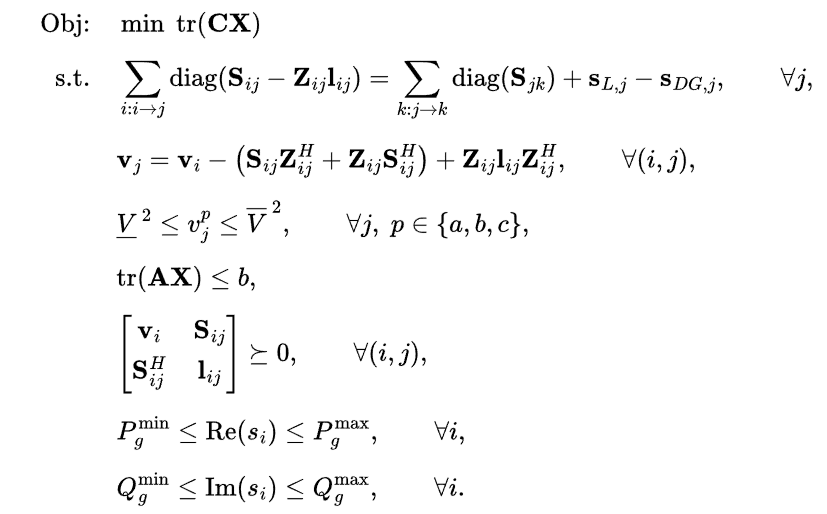

## 7. SDP OPF  Solution
This section defines the SDP OPF problem using CVXPY, sets up constraints, and solves for the optimal solution.

In [9]:
# Helper functions for SDP OPF
def get_Z_sub(brid):
    """Get sub-impedance matrix for a branch's active phases."""
    ph = branch_phases[brid]
    n = len(ph)
    Z_r = np.zeros((n, n))
    Z_i = np.zeros((n, n))
    for ii in range(n):
        for jj in range(n):
            Z_r[ii, jj] = R[ph[ii], ph[jj], brid]
            Z_i[ii, jj] = X[ph[ii], ph[jj], brid]
    return Z_r, Z_i

def get_W_parent_sub(parent_bus, child_phases):
    """Get sub-matrix indices of parent bus W corresponding to child's phases."""
    pp = phase_avail[parent_bus]
    idx = [pp.index(p) for p in child_phases]
    return idx

In [10]:
def solve_sdp_opf(Qcontrol=False):
    constraints = []

    # ─── Bus voltage matrices (Hermitian PSD) ───────────────────────────────
    # W_re[bus] is n×n symmetric, W_im[bus] is n×n skew-symmetric
    W_re = {}
    W_im = {}
    for bus in all_buses:
        n = nph[bus]
        W_re[bus] = cp.Variable((n, n), symmetric=True)
        W_im[bus] = cp.Variable((n, n))
        # Enforce skew-symmetry: W_im + W_im.T == 0, diag(W_im) == 0
        constraints.append(W_im[bus] + W_im[bus].T == 0)

    # ─── Branch current matrices and power matrices ─────────────────────────
    I_re = {}
    I_im = {}
    S_re = {}
    S_im = {}

    for brid in range(brs):
        n = len(branch_phases[brid])
        if n == 0:
            continue
        I_re[brid] = cp.Variable((n, n), symmetric=True)
        I_im[brid] = cp.Variable((n, n))
        constraints.append(I_im[brid] + I_im[brid].T == 0)

        S_re[brid] = cp.Variable((n, n))
        S_im[brid] = cp.Variable((n, n))

    # ─── Injected power at each bus ─────────────────────────────────────────
    s_re = {}
    s_im = {}
    for bus in all_buses:
        n = nph[bus]
        s_re[bus] = cp.Variable(n)
        s_im[bus] = cp.Variable(n)

    # ─── Slack bus voltage ──────────────────────────────────────────────────
    Wslack_re = np.array([[ 1.0,  -0.5,  -0.5],
                          [-0.5,   1.0,  -0.5],
                          [-0.5,  -0.5,   1.0]])
    Wslack_im = np.array([[ 0.0,       -np.sqrt(3)/2,  np.sqrt(3)/2],
                          [ np.sqrt(3)/2,  0.0,        -np.sqrt(3)/2],
                          [-np.sqrt(3)/2,  np.sqrt(3)/2,  0.0       ]])

    n_slack = nph[slack_bus]
    ph_slack = phase_avail[slack_bus]
    for i in range(n_slack):
        for j in range(n_slack):
            constraints.append(W_re[slack_bus][i, j] == Wslack_re[ph_slack[i], ph_slack[j]])
            constraints.append(W_im[slack_bus][i, j] == Wslack_im[ph_slack[i], ph_slack[j]])

    # ─── Voltage drop constraints ──────────────────────────────────────────
    for brid in range(brs):
        ph = branch_phases[brid]
        n = len(ph)
        if n == 0:
            continue

        from_bus = node1[brid]
        to_bus = node2[brid]
        Zr, Zi = get_Z_sub(brid)
        pidx = get_W_parent_sub(from_bus, ph)

        Wf_re = W_re[from_bus][np.ix_(pidx, pidx)]
        Wf_im = W_im[from_bus][np.ix_(pidx, pidx)]
        Sr = S_re[brid]
        Si = S_im[brid]
        Ir = I_re[brid]
        Ii = I_im[brid]
        Wt_re = W_re[to_bus]
        Wt_im = W_im[to_bus]

        # Z*I intermediate: A = Zr*Ir - Zi*Ii, B = Zr*Ii + Zi*Ir
        A_ZIZ = Zr @ Ir - Zi @ Ii
        B_ZIZ = Zr @ Ii + Zi @ Ir

        # S * Z^H: real = Sr*Zr' + Si*Zi', imag = Si*Zr' - Sr*Zi'
        SZH_re = Sr @ Zr.T + Si @ Zi.T
        SZH_im = Si @ Zr.T - Sr @ Zi.T

        # Z * S^H: real = Zr*Sr' + Zi*Si', imag = Zi*Sr' - Zr*Si'
        ZSH_re = Zr @ Sr.T + Zi @ Si.T
        ZSH_im = Zi @ Sr.T - Zr @ Si.T

        # Z * I * Z^H: real = A*Zr' + B*Zi', imag = B*Zr' - A*Zi'
        ZIZH_re = A_ZIZ @ Zr.T + B_ZIZ @ Zi.T
        ZIZH_im = B_ZIZ @ Zr.T - A_ZIZ @ Zi.T

        # Voltage drop
        constraints.append(Wt_re == Wf_re - SZH_re - ZSH_re + ZIZH_re)
        constraints.append(Wt_im == Wf_im - SZH_im - ZSH_im + ZIZH_im)

    # ─── SDP constraints: [W_from_sub  S; S'  I] ≽ 0 ──────────────────────
    for brid in range(brs):
        ph = branch_phases[brid]
        n = len(ph)
        if n == 0:
            continue

        from_bus = node1[brid]
        pidx = get_W_parent_sub(from_bus, ph)

        Wf_re = W_re[from_bus][np.ix_(pidx, pidx)]
        Wf_im = W_im[from_bus][np.ix_(pidx, pidx)]
        Sr = S_re[brid]
        Si = S_im[brid]
        Ir = I_re[brid]
        Ii = I_im[brid]

        # Build real 4n×4n PSD matrix
        # [Wf_re  -Wf_im   Sr   -Si ]
        # [Wf_im   Wf_re   Si    Sr ]
        # [Sr'     Si'     Ir   -Ii ]
        # [-Si'    Sr'     Ii    Ir ]
        M = cp.bmat([
            [Wf_re,  -Wf_im,  Sr,    -Si   ],
            [Wf_im,   Wf_re,  Si,     Sr   ],
            [Sr.T,     Si.T,  Ir,    -Ii   ],
            [-Si.T,    Sr.T,  Ii,     Ir   ]
        ])
        constraints.append(M >> 0)

    # ─── Power balance at each bus ─────────────────────────────────────────
    for bus in all_buses:
        ph = phase_avail[bus]
        n = nph[bus]
        if n == 0:
            continue

        bidx = bus_to_idx[bus]
        inc = incbr[bidx]
        out_brs = [ob for ob in outbr[bidx, :] if ob >= 0]

        for local_idx in range(n):
            p = ph[local_idx]

            # Incoming power minus line loss (diagonal element)
            inc_P_re = 0.0
            inc_P_im = 0.0
            if inc >= 0:
                inc_ph = branch_phases[inc]
                inc_n = len(inc_ph)
                if p in inc_ph:
                    inc_local = inc_ph.index(p)
                    Zr_inc, Zi_inc = get_Z_sub(inc)
                    k = inc_local

                    inc_P_re = S_re[inc][k, k]
                    for jj in range(inc_n):
                        inc_P_re = inc_P_re - Zr_inc[k, jj] * I_re[inc][jj, k] + Zi_inc[k, jj] * I_im[inc][jj, k]

                    inc_P_im = S_im[inc][k, k]
                    for jj in range(inc_n):
                        inc_P_im = inc_P_im - Zr_inc[k, jj] * I_im[inc][jj, k] - Zi_inc[k, jj] * I_re[inc][jj, k]

            # Outgoing power
            out_P_re = 0.0
            out_P_im = 0.0
            for ob in out_brs:
                ob_ph = branch_phases[ob]
                if p in ob_ph:
                    ob_local = ob_ph.index(p)
                    out_P_re = out_P_re + S_re[ob][ob_local, ob_local]
                    out_P_im = out_P_im + S_im[ob][ob_local, ob_local]

            # Load at this bus for phase p
            load_re = np.real(loadmat[p, bidx])
            load_im = np.imag(loadmat[p, bidx])

            # Power balance: s - load + incoming = outgoing
            constraints.append(s_re[bus][local_idx] - load_re + inc_P_re == out_P_re)
            constraints.append(s_im[bus][local_idx] - load_im + inc_P_im == out_P_im)

    # ─── Voltage magnitude bounds ──────────────────────────────────────────
    for bus in all_buses:
        if bus == slack_bus:
            continue
        n = nph[bus]
        for i in range(n):
            constraints.append(W_re[bus][i, i] >= Vmin_pu**2)
            constraints.append(W_re[bus][i, i] <= Vmax_pu**2)

    # ─── Generation / injection constraints ────────────────────────────────
    # Slack bus: bounded generation
    for local_idx in range(nph[slack_bus]):
        constraints.append(s_re[slack_bus][local_idx] >= -500)
        constraints.append(s_re[slack_bus][local_idx] <= 500)
        constraints.append(s_im[slack_bus][local_idx] >= -500)
        constraints.append(s_im[slack_bus][local_idx] <= 500)

    # Non-slack buses
    for bus in all_buses:
        if bus == slack_bus:
            continue
        ph = phase_avail[bus]
        n = nph[bus]
        bidx = bus_to_idx[bus]
        for local_idx in range(n):
            p = ph[local_idx]
            pv_val = PPv[bidx, p]
            if pv_val > 1e-10:
                # DG bus
                constraints.append(s_re[bus][local_idx] >= pv_val)
                constraints.append(s_re[bus][local_idx] <= pv_val)
                if Qcontrol:
                    qmax = 0.6633 * pv_val
                    constraints.append(s_im[bus][local_idx] >= -qmax)
                    constraints.append(s_im[bus][local_idx] <= qmax)
                else:
                    constraints.append(s_im[bus][local_idx] >= 0)
                    constraints.append(s_im[bus][local_idx] <= 0)
            else:
                # No generation
                constraints.append(s_re[bus][local_idx] == 0)
                constraints.append(s_im[bus][local_idx] == 0)



    # ─── Objective: minimize total real power loss ─────────────────────────
    # loss = Σ_brid tr(Zr*Ir - Zi*Ii)
    loss_expr = 0
    for brid in range(brs):
        ph = branch_phases[brid]
        n = len(ph)
        if n == 0:
            continue
        Zr, Zi = get_Z_sub(brid)
        loss_expr = loss_expr + cp.trace(Zr @ I_re[brid] - Zi @ I_im[brid])

    objective = cp.Minimize(loss_expr)
    problem = cp.Problem(objective, constraints)

    print("  Building complete. Solving SDP...")
    problem.solve(solver=cp.SCS, max_iters=200000, eps_abs=1e-8, eps_rel=1e-8, verbose=False)

    print(f"  Termination status : {problem.status}")
    if problem.value is not None:
        print(f"  Objective value    : {problem.value}")

    # ─── Extract voltage magnitudes ────────────────────────────────────────
    Vval = np.full((tnode, 3), np.nan)
    for bus in all_buses:
        ph = phase_avail[bus]
        n = nph[bus]
        bidx = bus_to_idx[bus]
        for local_idx in range(n):
            v_sq = W_re[bus].value[local_idx, local_idx]
            Vval[bidx, ph[local_idx]] = np.sqrt(max(v_sq, 0.0))

    # Extract loss value
    loss_val = problem.value

    # Extract substation power
    s_slack = np.zeros(3, dtype=complex)
    ph_s = phase_avail[slack_bus]
    for local_idx in range(nph[slack_bus]):
        s_slack[ph_s[local_idx]] = (s_re[slack_bus].value[local_idx]
                                    + 1j * s_im[slack_bus].value[local_idx])

    return Vval, loss_val, s_slack, W_re, W_im, I_re, I_im

In [11]:
print("\n" + "=" * 60)
print("  Case 1:  WITH DG Q-control (Qcontrol=True)")
print("=" * 60)
Vval_control, loss_control, s_slack_ctrl, W_re_ctrl, W_im_ctrl, I_re_ctrl, I_im_ctrl = solve_sdp_opf(Qcontrol=True)




  Case 1:  WITH DG Q-control (Qcontrol=True)
  Building complete. Solving SDP...
  Termination status : optimal
  Objective value    : 0.12964235100181987


In [12]:
# Solve both cases and print results
print("\n" + "=" * 60)
print("  Case 2:  WITHOUT DG Q-control (Qcontrol=False)")
print("=" * 60)
Vval_nocontrol, loss_nocontrol, s_slack_nc, W_re_nc, W_im_nc, I_re_nc, I_im_nc = solve_sdp_opf(Qcontrol=False)

print("\n─── SDP Results ──────────────────────────────────────────")
print(f"Loss without DG Q-control : {loss_nocontrol:.6f} p.u. = {loss_nocontrol * baseMVA / 1000:.4f} kW")
print(f"Loss with DG Q-control    : {loss_control:.6f} p.u. = {loss_control * baseMVA / 1000:.4f} kW")

print("\nSubstation power (with Q-control):")
for p in range(3):
    print(f"  Phase {p+1}: P = {s_slack_ctrl[p].real:.4f} p.u., Q = {s_slack_ctrl[p].imag:.4f} p.u.")




  Case 2:  WITHOUT DG Q-control (Qcontrol=False)
  Building complete. Solving SDP...
  Termination status : optimal
  Objective value    : 0.16256616378768582

─── SDP Results ──────────────────────────────────────────
Loss without DG Q-control : 0.162566 p.u. = 162.5662 kW
Loss with DG Q-control    : 0.129642 p.u. = 129.6424 kW

Substation power (with Q-control):
  Phase 1: P = -1.6343 p.u., Q = 0.0380 p.u.
  Phase 2: P = -1.0882 p.u., Q = 0.0239 p.u.
  Phase 3: P = -1.8828 p.u., Q = -0.1290 p.u.


In [13]:
output_dir = os.getcwd()
os.makedirs(output_dir, exist_ok=True)
excel_out_ctrl = os.path.join(output_dir, "Voltage with DG Control (SDP).xlsx")
wb_out_ctrl = openpyxl.Workbook()
ws_out_ctrl = wb_out_ctrl.active
ws_out_ctrl.title = "With_DG_Control"

ws_out_ctrl.append(["Node", "Phase A", "Phase B", "Phase C"])
for row_idx, bus in enumerate(idx):
    row_vals = [int(bus)]
    for ph in range(3):
        v = Vval_control[row_idx, ph]
        row_vals.append(None if np.isnan(v) else float(round(v, 5)))
    ws_out_ctrl.append(row_vals)

wb_out_ctrl.save(excel_out_ctrl)
print(f"Saved Excel file: {excel_out_ctrl}")

Saved Excel file: /content/Voltage with DG Control (SDP).xlsx


In [14]:
# Save the "without DG control" voltages to Excel
output_dir = os.getcwd()
os.makedirs(output_dir, exist_ok=True)
excel_out = os.path.join(output_dir, "Voltage without DG Control (SDP).xlsx")
wb_out = openpyxl.Workbook()
ws_out = wb_out.active
ws_out.title = "Without_DG_Control"

ws_out.append(["Node", "Phase A", "Phase B", "Phase C"])
for row_idx, bus in enumerate(idx):
    row_vals = [int(bus)]
    for ph in range(3):
        v = Vval_nocontrol[row_idx, ph]
        row_vals.append(None if np.isnan(v) else float(round(v, 5)))
    ws_out.append(row_vals)

wb_out.save(excel_out)
print(f"Saved Excel file: {excel_out}")

Saved Excel file: /content/Voltage without DG Control (SDP).xlsx


In [15]:
print("\n─── Voltage Magnitudes (with DG Q-control — SDP) ────────")

print(f"{'Node':>6s}  {'Phase A':>10s}  {'Phase B':>10s}  {'Phase C':>10s}")
for row_idx, bus in enumerate(idx):
    vals = []
    for p in range(3):
        if np.isnan(Vval_control[row_idx, p]):
            vals.append("   ---   ")
        else:
            vals.append(f"  {Vval_control[row_idx, p]:.5f}")
    print(f"{int(bus):6d}  {vals[0]:>10s}  {vals[1]:>10s}  {vals[2]:>10s}")

print("\n─── Voltage Magnitudes (without DG Q-control — SDP) ─────")
print(f"{'Node':>6s}  {'Phase A':>10s}  {'Phase B':>10s}  {'Phase C':>10s}")
for row_idx, bus in enumerate(idx):
    vals = []
    for p in range(3):
        if np.isnan(Vval_nocontrol[row_idx, p]):
            vals.append("   ---   ")
        else:
            vals.append(f"  {Vval_nocontrol[row_idx, p]:.5f}")
    print(f"{int(bus):6d}  {vals[0]:>10s}  {vals[1]:>10s}  {vals[2]:>10s}")


─── Voltage Magnitudes (with DG Q-control — SDP) ────────
  Node     Phase A     Phase B     Phase C
     1     1.00789     1.00304     1.00885
     2      ---        1.00281      ---   
     3      ---         ---        1.01713
     4      ---         ---        1.01661
     5      ---         ---        1.02302
     6      ---         ---        1.02790
     7     1.01247     1.00880     1.01187
     8     1.01574     1.01268     1.01386
     9     1.02125      ---         ---   
    10     1.03254      ---         ---   
    11     1.04007      ---         ---   
    12      ---        1.01239      ---   
    13     1.01818     1.01660     1.01921
    14     1.03286      ---         ---   
    15      ---         ---        1.02190
    16      ---         ---        1.02701
    17      ---         ---        1.02144
    18     1.02532     1.02002     1.02252
    19     1.02404      ---         ---   
    20     1.02320      ---         ---   
    21     1.02890     1.02114     1.0

## 8. Plot Results

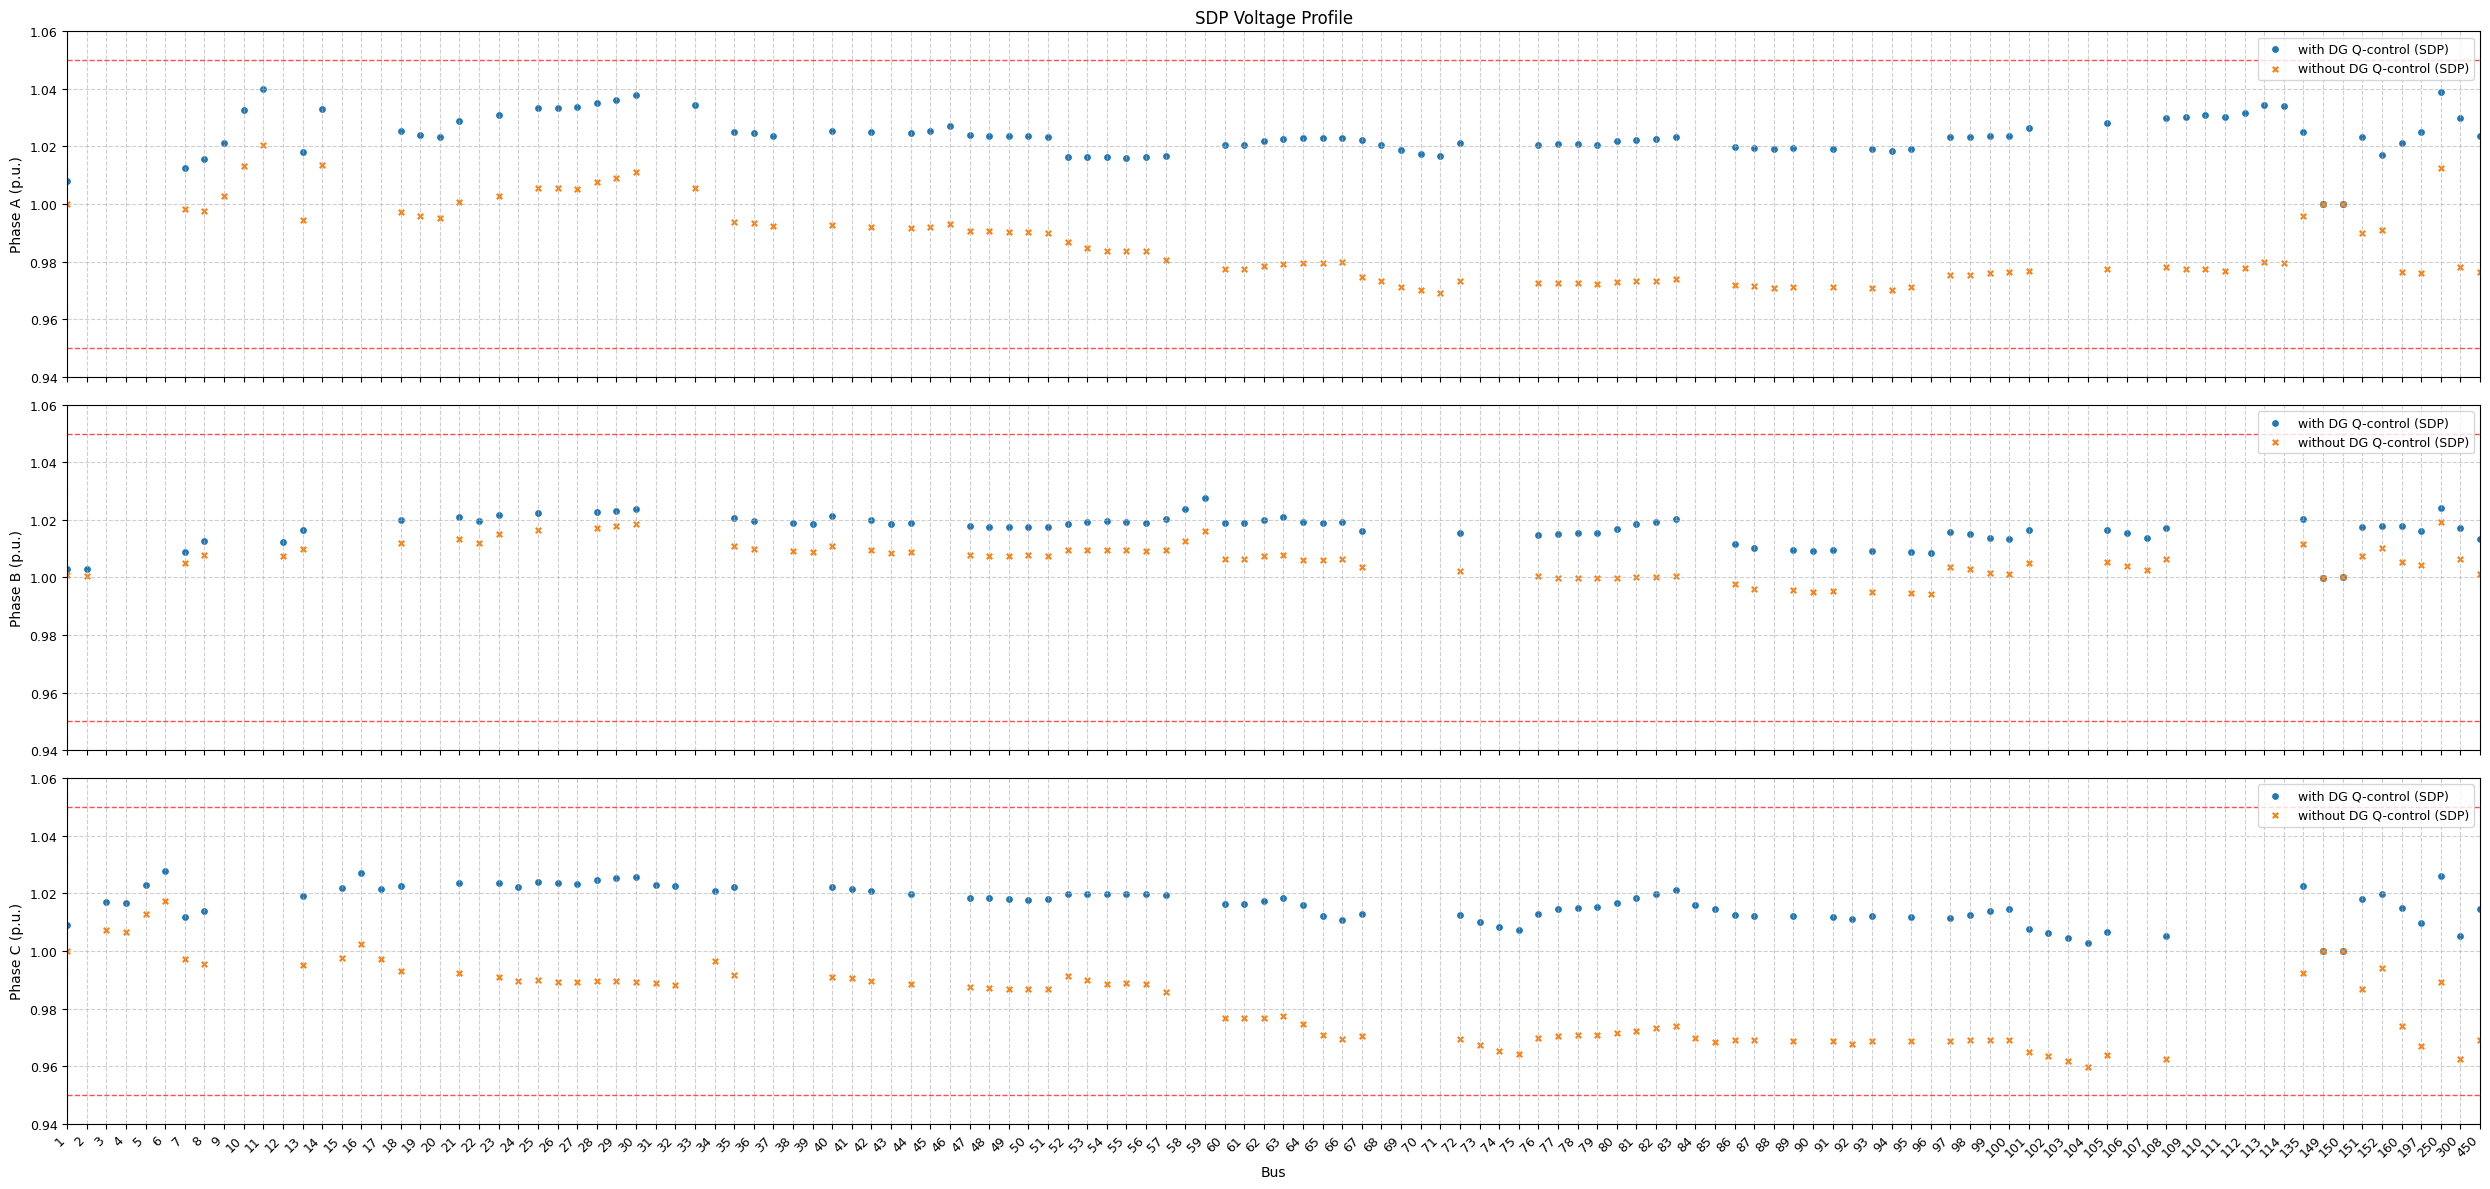

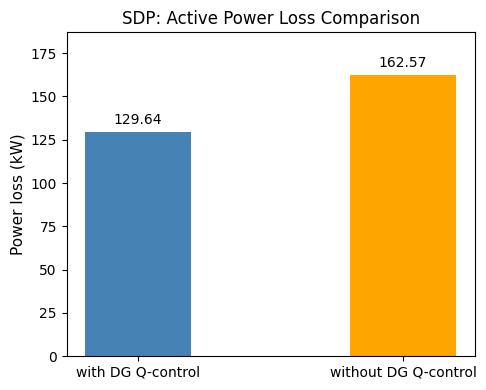

In [16]:
# Plot voltage profiles and loss comparison
buses = idx
x_labels = list(all_buses)
x_pos = np.arange(len(x_labels))
fig, axes = plt.subplots(3, 1, figsize=(25, 12), sharex=True)
phase_labels = ["Phase A", "Phase B", "Phase C"]

for idx_phase, ax in enumerate(axes):
    ax.scatter(x_pos, Vval_control[:, idx_phase], marker='o', s=15, label="with DG Q-control (SDP)")
    ax.scatter(x_pos, Vval_nocontrol[:, idx_phase], marker='x', s=15, label="without DG Q-control (SDP)")

    ax.set_ylabel(f"{phase_labels[idx_phase]} (p.u.)")
    ax.set_xlim(0, len(x_labels) - 1)
    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.legend(loc="upper right", fontsize=9)
    ax.tick_params(labelsize=9)
    ax.set_ylim(0.94, 1.06)
    ax.horizontal_line = ax.axhline(0.95, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.horizontal_line = ax.axhline(1.05, color='red', linestyle='--', linewidth=1, alpha=0.7)

    ax.grid(True, linestyle='--', alpha=0.6)

axes[-1].set_xlabel("Bus")
axes[0].set_title("SDP Voltage Profile")
plt.tight_layout()
plt.savefig(os.path.join(script_dir, "sdp_voltage_profile.png"), dpi=300)
plt.show()

# Loss comparison bar chart
fig2, ax2 = plt.subplots(figsize=(5, 4))
loss_kW = [loss_control * baseMVA / 1000, loss_nocontrol * baseMVA / 1000]

bars = ax2.bar(["with DG Q-control", "without DG Q-control"], loss_kW,
               width=0.4, color=["steelblue", "orange"])
ax2.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)
ax2.set_ylabel("Power loss (kW)", fontsize=11)
ax2.set_title("SDP: Active Power Loss Comparison")
ax2.set_ylim(0, max(loss_kW) * 1.15)
ax2.tick_params(labelsize=10)
plt.tight_layout()
plt.savefig(os.path.join(script_dir, "sdp_loss_comparison.png"), dpi=300)
plt.show()